# Olink proteomics dataset  

### Description 
The HPP Olink dataset contains relative protein expression profiles for thousands of proteins measured in plasma from HPP participants, using Olink Reveal, an NGS‑based Proximity Extension Assay (PEA) platform. Each assay uses pairs of antibodies coupled to DNA oligos: when both antibodies bind the same protein, their oligos come into proximity, are extended, PCR‑amplified, and quantified via Illumina sequencing ([Multiplex high-throughput proteomics with exceptional analytical specificity |  illumina in collaboration with Olink](https://www.illumina.com/content/dam/illumina/gcs/assembled-assets/marketing-literature/olink-proteomics-tech-note-m-us-00196/olink-proteomics-tech-note-m-us-00196.pdf), [Wik, Lotta, et al, 2021](https://www.sciencedirect.com/science/article/pii/S1535947621001407)).

The primary quantitative output is **NPX (Normalized Protein eXpression)**, a log₂‑scaled, normalized value per protein, per sample. NPX is relative, not absolute concentration; within an assay, differences in NPX can be treated as relative fold changes (ΔNPX ≈ log₂ fold change).


### Introduction 
The Human Phenotype Project (HPP) aims to deeply characterize participants using multi‑omics, imaging, physiology, and longitudinal follow‑up. Proteins are proximal effectors of genes and often more closely related to disease biology than the genome alone; high‑plex proteomics adds dynamic information about inflammation, metabolism, tissue damage and signaling.

Olink Reveal was chosen as the first large‑scale proteomics platform for HPP because it:
* Provides >1,000 proteins per sample from small volumes of plasma ([Olink data normalization white paper | Olink](https://7074596.fs1.hubspotusercontent-na1.net/hubfs/7074596/05-white%20paper%20for%20website/1096-olink-data-normalization-white-paper.pdf)). 
* Has a robust QC and normalization framework (internal/external controls, NPX, inter‑plate normalization).
* Integrates naturally with Illumina NGS, allowing alignment with existing infrastructure and expertise.


### Measurement protocol 

#### Lab equipment
**Sample prep:** Automated pipetting using Tecan robots.

**Sequencing:** Illumina NovaSeq 6000, generating paired‑end NGS reads that encode PEA probe counts per assay.

#### Controls and plate layout
Per the HPP Olink design and Olink recommendations:
* **Internal controls (spiked into each sample)**  designed to monitor the three main steps of the Olink protocol: Immunoreaction, extension, and amplification/detection (Figure 1).
    * Incubation Control 1 & 2: monitor overall reaction / matrix effects.
    * Extension Control: monitors extension + amplification/detection, used for within‑sample normalization.
    * Detection Control: monitors amplification/detection only.
* **External controls (dedicated wells per plate, Figure 2)**
    * Inter‑Plate Controls (IPC, triplicates): synthetic high‑signal samples used for inter‑plate normalization.
    * Negative Controls (triplicates): buffer only; used to monitor background and define LOD.
    * Sample controls (pooled plasma, duplicates): monitor intra‑/inter‑assay CV across plates.
* **Randomization**
    * Within each batch, samples are balanced and randomized for age, sex, and other key HPP covariates, so that plate medians are comparable and intensity normalization remains valid.

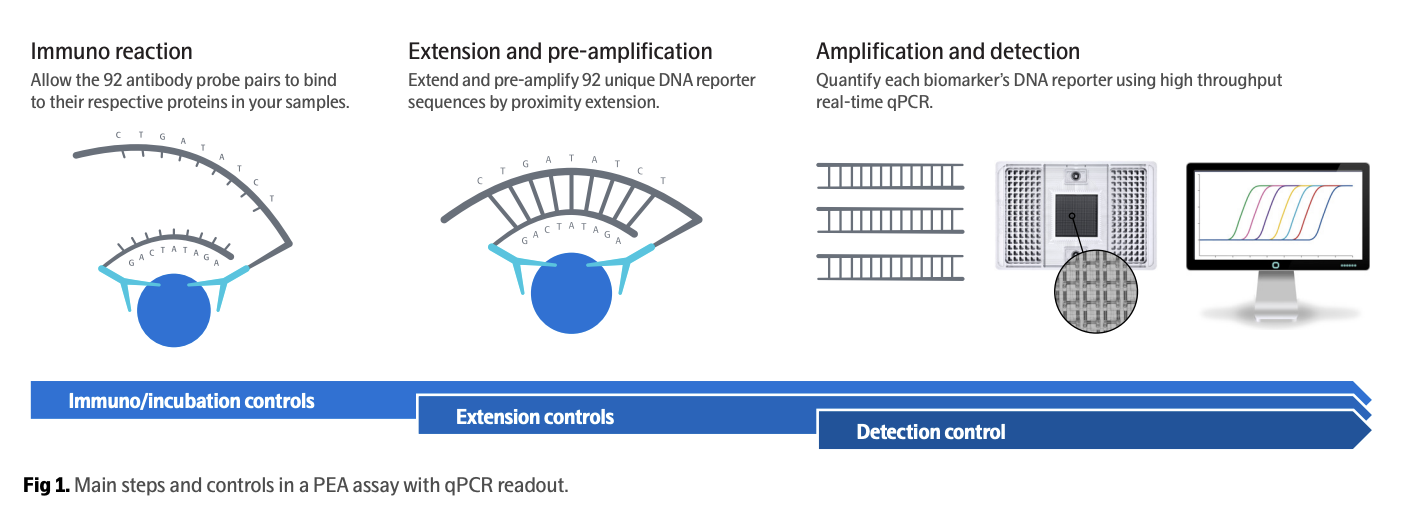

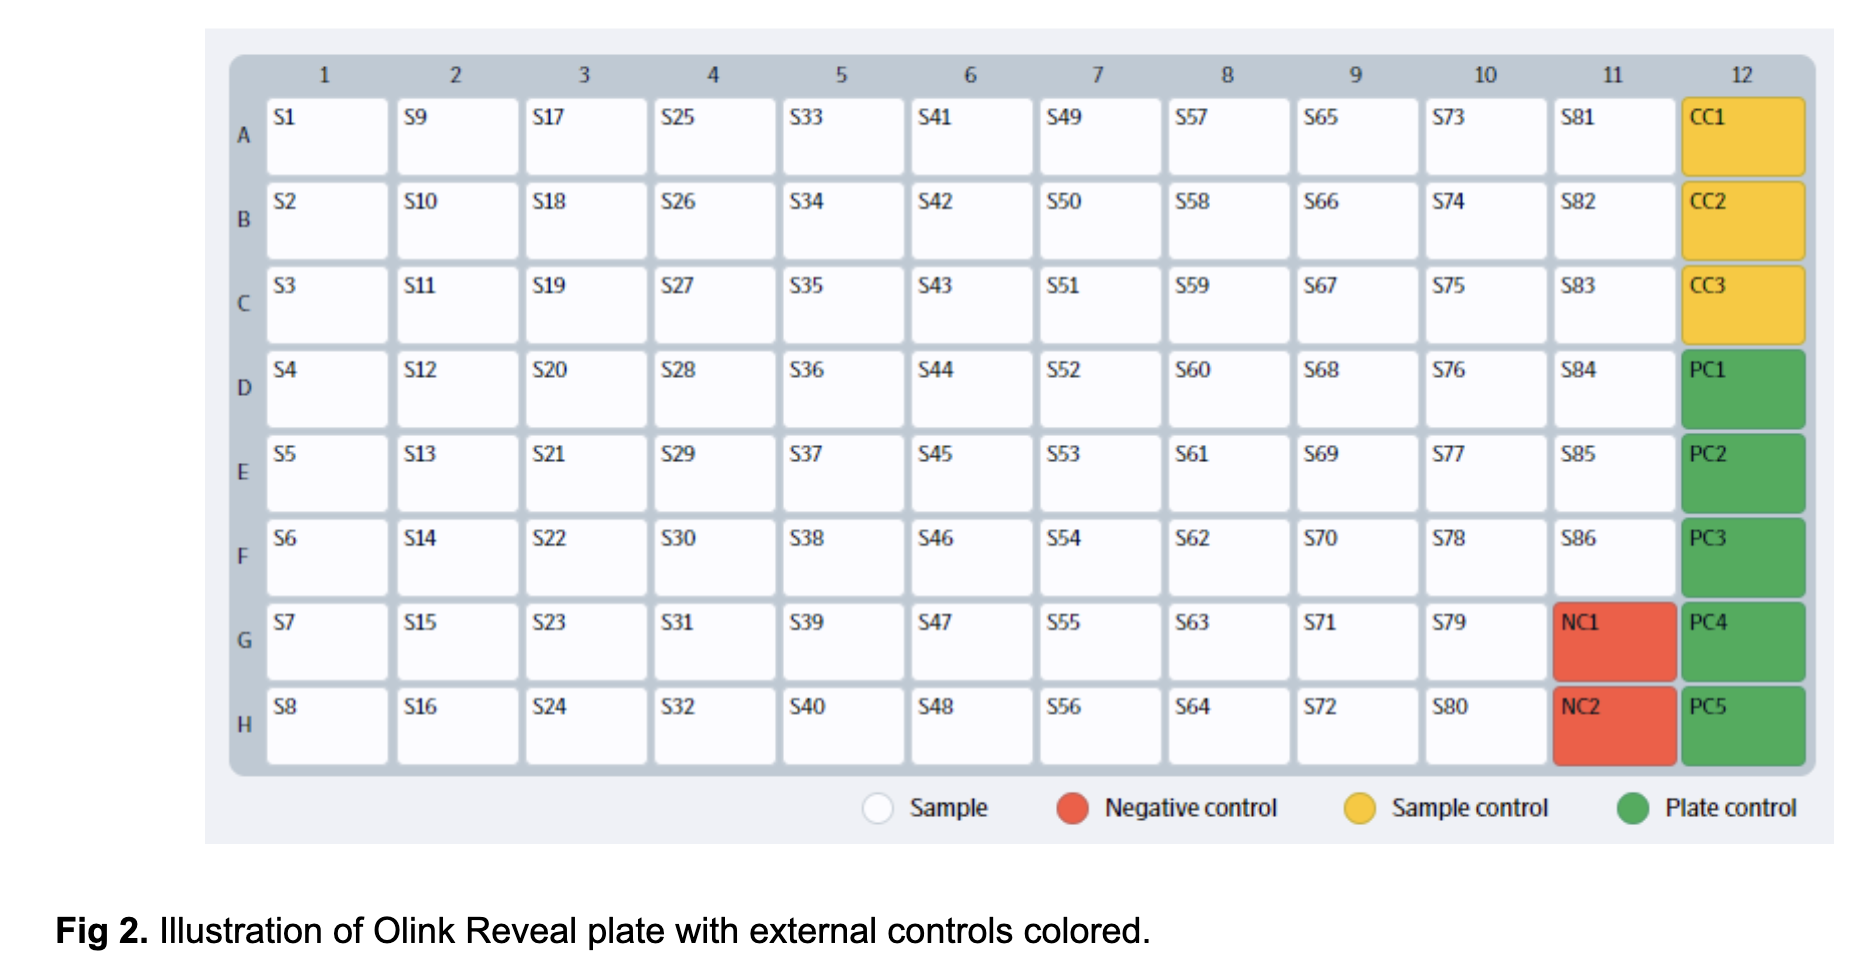

#### Technology & NPX scale

##### Olink Reveal platform

* Reveal is an NGS‑based proteomics solution built on Olink’s PEA technology, measuring ~1,000 proteins per sample from ~4–25 μL plasma/serum ([Olink Reveal: Revolutionizing High-Throughput Proteomics | Protavio Team](https://protavio.com/news-olink-reveal/)).
* Panels are curated to cover cardiometabolic, inflammatory, neurology, oncology and other key pathways with broad proteome coverage.

##### NPX computation (conceptual)
For qPCR‑based Olink platforms, NPX is derived from Ct values using:
1. Extension control normalization (ΔCt vs extension control).
2. IPC normalization (ΔΔCt vs IPC).
3. Panel‑specific correction factor to orient the scale so that higher NPX = higher protein abundance and background ≈ 0.

For NGS‑based platforms (Reveal/Explore), the exact calculations differ, but NPX retains the same conceptual properties:
1. Log₂‑like unit, relative per assay.
2. Roughly: ΔNPX = 1 → ~2× fold change ([What Does the Olink NPX Value Represent? Guidelines for Accurate Interpretation of Protein Expression Data | MtoZ Biolabs Services](https://www.mtoz-biolabs.com/what-does-the-olink-npx-value-represent-guidelines-for-accurate-interpretation-of-protein-expression-data.html))

**Interpretation guidelines**
* Compare NPX within the same assay (e.g., IL‑6 across individuals or timepoints), not across different proteins.
* Cross‑run / cross‑plate comparisons are valid after the specified normalization steps (IPC/intensity + any bridge normalization).


### Data availability 
<!-- for the example notebooks -->
* **Raw NGS output (Illumina BCL)**
    * One BCL directory per sequencing run.
* **BCL detection & validation (Dagster)**
    * Auto‑detect runs under /day2data/illumina/.
    * Validate BCL structure, presence of RunInfo, sample sheet, and Olink recipe files.
* **BCL → counts (ngs2counts, Olink propraietary SW)**
    * Run in Docker; outputs assay‑level count matrices per run/plate.
* **Counts → NPX (npx_map_cli, Olink propraietary SW)**
    * Vendor npx_map_cli tool converts counts + plate metadata into NPX tables, with vendor QC flags and internal/external control information.
* **Pheno QC pipeline**
    * Apply sample/assay QC filters.
    * Remove failed run and per‑run assay QC warnings.
    * PCA + median–IQR outlier detection.
    * IntraCV/interCV‑based filtering of noisy assays.
    * Bridge normalization for outlier run(s)
    * LOD analysis and % below LOD summaries.
* **Final dataset assembly** - temporary location: `s3://datasets-development/olink/dataset/` in the DS account
    * Long‑format NPX tables with all QC columns + LOD (`5_olink_npx_data_lod_added.parquet`)
    * External controls with all QC columns (no LOD) (`4_olink_npx_controls_cv_qc.parquet`)
    * LOD per assay (protein) information (`5_olink_lod_per_assay.parquet`)
* **Research stage filling** - temporary location: `s3://ds-users/anat/olink_eda/`
    * `olink_npx_events_filled_multiindex.parquet` - dataset after filling missing research stages and adding PhenoLoader-compatible multi-index (`['participant_id', 'cohort', 'research_stage', 'array_index']`)

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pheno_utils import PhenoLoader
from pheno_utils.basic_plots import hist_ecdf_plots

# Set display options
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Olink Data

Load the Olink proteomics data directly from S3. The data has a multi-index format compatible with PhenoLoader.

In [3]:
# Load Olink data from S3
df_olink = pd.read_parquet('s3://ds-users/anat/olink_eda/olink_npx_events_filled_multiindex.parquet')

print(f"Shape: {df_olink.shape}")
print(f"Index levels: {df_olink.index.names}")
print(f"\nNumber of unique participants: {df_olink.index.get_level_values('participant_id').nunique():,}")
print(f"Number of unique research stages: {df_olink.index.get_level_values('research_stage').nunique()}")

# Preview the data
df_olink.head()

Shape: (6200301, 87)
Index levels: ['participant_id', 'cohort', 'research_stage', 'array_index']

Number of unique participants: 5,073
Number of unique research stages: 6


SampleID SampleType  \
participant_id cohort research_stage array_index                            
814716865      10k                   0            LV1003675194     SAMPLE   
                                     1            LV1003675194     SAMPLE   
                                     2            LV1003675194     SAMPLE   
                                     3            LV1003675194     SAMPLE   
                                     4            LV1003675194     SAMPLE   

                                                 WellID PlateID  \
participant_id cohort research_stage array_index                  
814716865      10k                   0              H10  plate1   
                                     1              H10  plate1   
                                     2              H10  plate1   
                                     3              H10  plate1   
                                     4              H10  plate1   

                                                 DataAnalysisRefID   OlinkID  \
participant_id cohort research_stage array_index                               
814716865      10k                   0                      R10001  OID50348   
                                     1                      R10001  OID50349   
                                     2                      R10001  OID50086   
                                     3                      R10001  OID51017   
                                     4                      R10001  OID50350   

                                                 UniProt   Assay AssayType  \
participant_id cohort research_stage array_index                             
814716865      10k                   0            Q7Z7G0  ABI3BP     assay   
                                     1            P00519    ABL1     assay   
                                     2            P09110   ACAA1     assay   
                                     3            P16112    ACAN     assay   
                                     4            Q9BYF1    ACE2     assay   

                                                   Panel Block  Count  \
participant_id cohort research_stage array_index                        
814716865      10k                   0            Reveal     1  38394   
                                     1            Reveal     1   2183   
                                     2            Reveal     1   1227   
                                     3            Reveal     1  69526   
                                     4            Reveal     1   1763   

                                                    ExtNPX       NPX  \
participant_id cohort research_stage array_index                       
814716865      10k                   0            1.226130 -0.267452   
                                     1           -2.910367 -0.405341   
                                     2           -3.741544 -0.042878   
                                     3            2.082802 -0.111881   
                                     4           -3.218647 -0.171178   

                                                 Normalization  \
participant_id cohort research_stage array_index                 
814716865      10k                   0               Intensity   
                                     1               Intensity   
                                     2               Intensity   
                                     3               Intensity   
                                     4               Intensity   

                                                  PCNormalizedNPX AssayQC  \
participant_id cohort research_stage array_index                            
814716865      10k                   0                   1.117103    PASS   
                                     1                  -1.988411    PASS   
                                     2                  -1.352201    PASS   
                                     3                   0.293023    PA

In [4]:
# Check how many rows have filled vs empty research_stage in the multi-index
print(f"\n{'=' * 60}")
print("RESEARCH STAGE COVERAGE IN MULTI-INDEX")
print(f"{'=' * 60}")
research_stages = df_olink.index.get_level_values('research_stage')
filled_mask = (research_stages != '') & (~research_stages.isna())
filled_count = filled_mask.sum()
empty_count = len(df_olink) - filled_count

print(f"\nTotal rows: {len(df_olink):,}")
print(f"  With FILLED research_stage: {filled_count:,} ({filled_count/len(df_olink)*100:.2f}%)")
print(f"  With EMPTY research_stage:  {empty_count:,} ({empty_count/len(df_olink)*100:.2f}%)")

print(f"\nResearch stage distribution in multi-index:")
rs_counts = pd.Series(research_stages).value_counts(dropna=False)
for stage, count in rs_counts.items():
    stage_display = stage if stage else '(empty)'
    print(f"  {stage_display}: {count:,} ({count/len(df_olink)*100:.1f}%)")


RESEARCH STAGE COVERAGE IN MULTI-INDEX

Total rows: 6,200,301
  With FILLED research_stage: 6,170,077 (99.51%)
  With EMPTY research_stage:  30,224 (0.49%)

Research stage distribution in multi-index:
  00_00_visit: 4,911,881 (79.2%)
  02_00_visit: 1,067,239 (17.2%)
  04_00_visit: 162,631 (2.6%)
  (empty): 30,224 (0.5%)
  01_01_visit: 17,190 (0.3%)
  03_01_visit: 11,136 (0.2%)


## 2. Demographics

Load events data from PhenoLoader to get participant demographics (age, sex) for the Olink cohort.

In [5]:
# Load events data for demographics
pl_events = PhenoLoader('events')
df_events = pl_events[pl_events.fields]

# Get Olink participant IDs
olink_participants = df_olink.index.get_level_values('participant_id').unique()

# Filter events to Olink participants
df_olink_events = df_events[df_events.index.get_level_values('participant_id').isin(olink_participants)]

print(f"Found demographics for {df_olink_events.index.get_level_values('participant_id').nunique():,} Olink participants")

Found demographics for 5,047 Olink participants


/home/ec2-user/pheno-utils/pheno_utils/questionnaires_handler.py:95: UserWarning: Invalid values found: {'22', '24', '26', '25'}
  warnings.warn(f"Invalid values found: {invalid_values}")


In [6]:
# Create demographics summary (first record per participant)
df_demographics = df_olink_events.reset_index().groupby('participant_id').first()[['sex', 'age_at_research_stage']]

print("Gender Distribution:")
print(df_demographics['sex'].value_counts())

print("\nAge Statistics:")
display(df_demographics['age_at_research_stage'].describe().to_frame().T)

Gender Distribution:
sex
Female    2606
Male      2441
Name: count, dtype: int64

Age Statistics:


,count,mean,std,min,25%,50%,75%,max
age_at_research_stage,5047.0,52.961343,8.233722,22.3,46.45,51.8,58.65,81.2


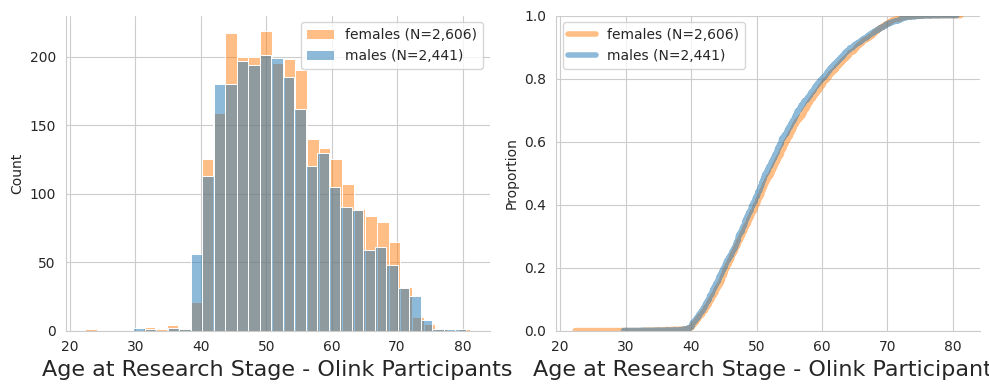

In [7]:
# Plot age distribution by sex
hist_ecdf_plots(df_demographics.reset_index(), 'age_at_research_stage', gender_col='sex', 
                feature_str='Age at Research Stage - Olink Participants')

## 3. NPX Data Overview

Explore the NPX (Normalized Protein eXpression) values - the main measurement in Olink data.

The dataset contains several NPX calculations:
* `ExtNPX` : The 2-log of the ratio between the 'Count' value of the data point and the 'Count' value for the Extension control assay.
* `NPX`: the Olink normalized NPX, according to the chosen normalization (the final NPX from Olink NPX Map software)
* `NPX_bridged`: the final NPX, after we (Pheno) applied bridge normalization for a small number of runs with outlier measurements in the external controls. For runs not requiring this normalization, it's the same as the `NPX`. **This is the final NPX that should be used** 

In [9]:
# NPX column overview
print("NPX Statistics (all proteins):")
display(df_olink['NPX_bridged'].describe().to_frame().T)

print(f"\nNumber of unique proteins (Assay): {df_olink['Assay'].nunique()}")
print(f"\nSample of protein names:")
print(df_olink['Assay'].unique()[:10])

NPX Statistics (all proteins):


,count,mean,std,min,25%,50%,75%,max
NPX_bridged,6200301.0,0.028205,0.60719,-8.398744,-0.272455,-0.005226,0.270277,11.619459



Number of unique proteins (Assay): 1028

Sample of protein names:
['ABI3BP', 'ABL1', 'ACAA1', 'ACAN', 'ACE2', 'ACP1', 'ACP3', 'ACP6', 'ACRV1', 'ACVRL1']
Categories (1037, object): ['ABI3BP', 'ABL1', 'ACAA1', 'ACAN', ..., 'ZC3H12A', 'ZC3H12D', 'ZER1', 'ZFAND2B']


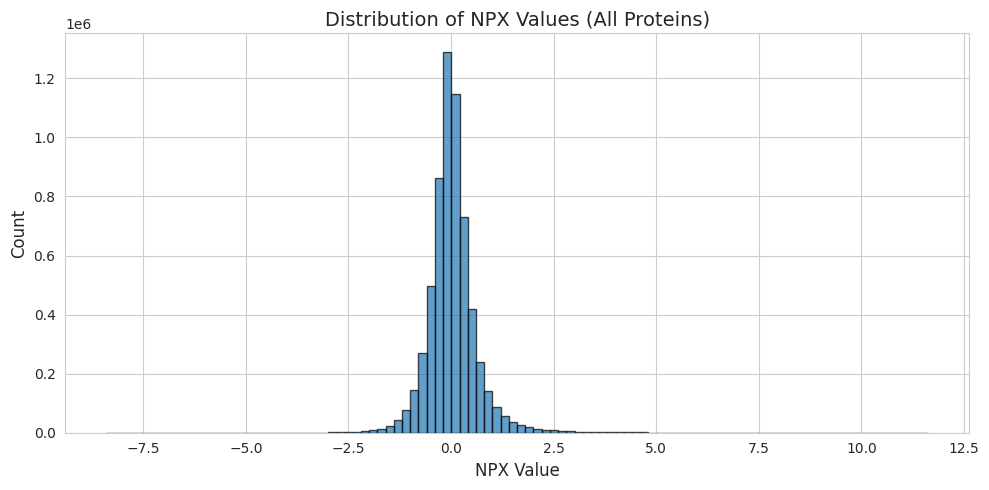

In [10]:
# Plot overall NPX distribution
fig, ax = plt.subplots(figsize=(10, 5))
df_olink['NPX_bridged'].hist(bins=100, ax=ax, alpha=0.7, edgecolor='black')
ax.set_xlabel('NPX Value', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of NPX Values (All Proteins)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Single Protein Analysis

Analyze a specific protein across participants. NPX values should be compared **within the same protein**.

Protein: IL6
Number of measurements: 6,138

NPX Statistics:


,count,mean,std,min,25%,50%,75%,max
NPX,6138.0,0.117409,0.903421,-2.033705,-0.47692,0.000201,0.55566,9.669533


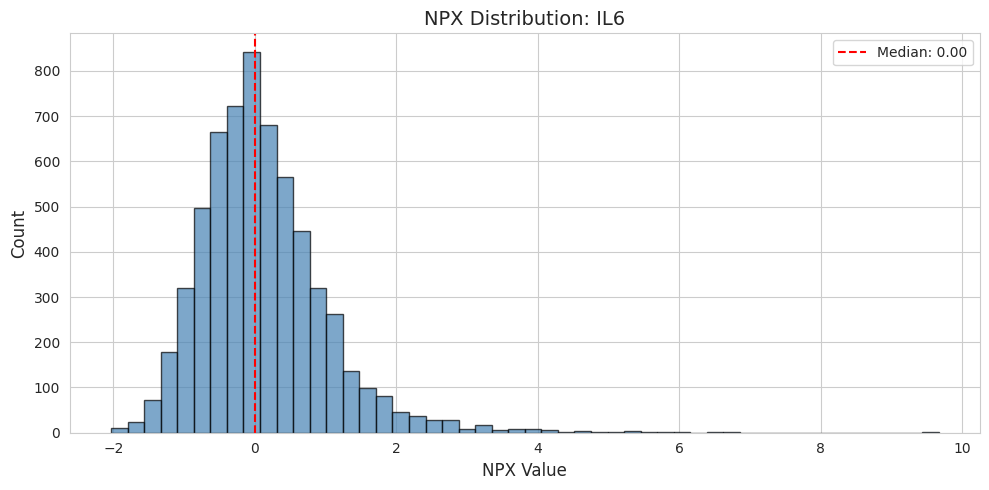

In [10]:
# Select a well-known protein (e.g., IL-6)
protein_of_interest = 'IL6'  # Interleukin-6

# Filter data for this protein
df_protein = df_olink[df_olink['Assay'] == protein_of_interest].copy()

if len(df_protein) > 0:
    print(f"Protein: {protein_of_interest}")
    print(f"Number of measurements: {len(df_protein):,}")
    print(f"\nNPX Statistics:")
    display(df_protein['NPX'].describe().to_frame().T)
    
    # Plot distribution
    fig, ax = plt.subplots(figsize=(10, 5))
    df_protein['NPX'].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_xlabel('NPX Value', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'NPX Distribution: {protein_of_interest}', fontsize=14)
    ax.axvline(df_protein['NPX'].median(), color='red', linestyle='--', label=f'Median: {df_protein["NPX"].median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Protein '{protein_of_interest}' not found. Available proteins:")
    print(df_olink['Assay'].unique()[:20])

## 5. Research Stage Distribution

Examine the distribution of samples across research stages.

Approximate samples per research stage:
research_stage
00_00_visit    4778
02_00_visit    1038
04_00_visit     158
                 29
01_01_visit      16
03_01_visit      10
Name: count, dtype: int64


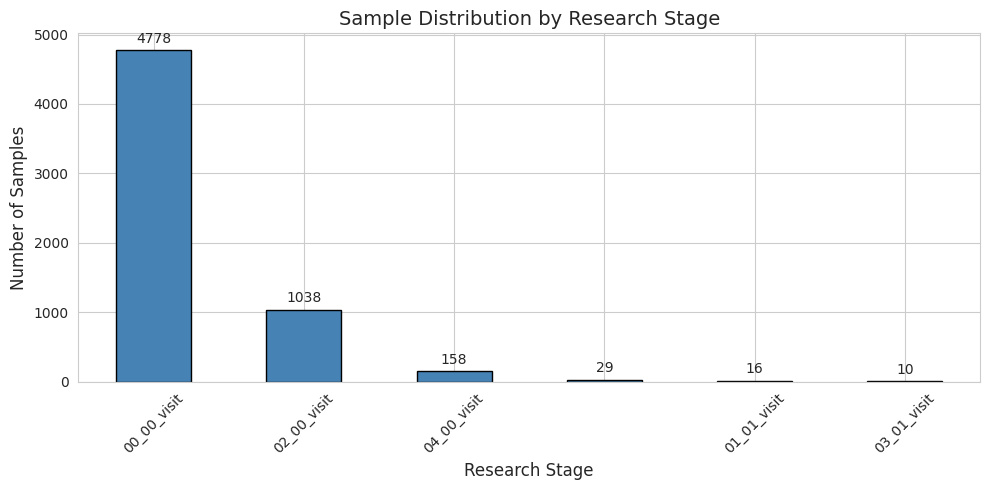

In [12]:
# Count unique samples per research stage
research_stages = df_olink.index.get_level_values('research_stage')
stage_counts = research_stages.value_counts()

# Since each sample has ~1000 proteins, divide by approximate protein count for sample count
n_proteins = df_olink['Assay'].nunique()
sample_counts = (stage_counts / n_proteins).astype(int)

print("Approximate samples per research stage:")
print(sample_counts)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = sample_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Research Stage', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Sample Distribution by Research Stage', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

## 6. Quality Control Columns

The dataset includes several QC columns for filtering.

In [13]:
# List QC-related columns
qc_cols = [col for col in df_olink.columns if 'qc' in col.lower() or 'QC' in col]
print("QC-related columns:")
for col in qc_cols:
    print(f"  - {col}")

# Check LOD (Limit of Detection) status
if 'LOD_status' in df_olink.columns:
    print("\nLOD Status Distribution:")
    print(df_olink['LOD_status'].value_counts())

if 'below_LOD' in df_olink.columns:
    print(f"\nMeasurements below LOD: {df_olink['below_LOD'].sum():,} ({df_olink['below_LOD'].mean()*100:.1f}%)")

QC-related columns:
  - AssayQC
  - SampleQC
  - SampleBlockQCWarn
  - SampleBlockQCFail
  - BlockQCFail
  - AssayQCWarn
  - qc_is_analytical_assay
  - qc_pass_recommended
  - qc_sample_passed
  - qc_assay_not_warned_in_run
  - qc_sample_pca_pass
  - qc_sample_median_iqr_pass
  - qc_intracv_pass
  - qc_intercv_pass

LOD Status Distribution:
LOD_status
Valid                6199873
Insufficient_Data        428
Name: count, dtype: int64

Measurements below LOD: 839,090 (13.5%)


## Summary

This notebook demonstrated:

1. **Loading** Olink proteomics data from S3 (multi-index format)
2. **Demographics** of Olink participants (age, sex distribution)
3. **NPX overview** - distribution of protein expression values
4. **Single protein analysis** - examining one protein across samples
5. **Research stage distribution** - sample counts per visit
6. **QC columns** - quality control flags available

### Key Columns

| Column | Description |
|--------|-------------|
| `NPX_bridged` | Normalized Protein eXpression (log2-scale) |
| `Assay` | Protein name |
| `OlinkID` | Olink protein identifier |
| `UniProt` | UniProt accession |
| `Gene name` | Gene name |
| `Protein name` | Protein name |
| `Explore 384 panel` | Explore 384 panel classification |
| `LOD` | Limit of Detection |
| `below_LOD` | Whether measurement is below LOD |

In [17]:
# Display key columns
key_columns = ['NPX_bridged', 'Assay', 'OlinkID', 'UniProt', 'Gene name', 'Protein name', 'Explore 384 panel', 'LOD', 'below_LOD']

# Filter to columns that exist in the dataframe
available_key_cols = [col for col in key_columns if col in df_olink.columns]
print(f"Key columns available: {available_key_cols}")

df_olink[available_key_cols].head(10)

Key columns available: ['NPX_bridged', 'Assay', 'OlinkID', 'UniProt', 'Gene name', 'Protein name', 'Explore 384 panel', 'LOD', 'below_LOD']


NPX_bridged   Assay  \
participant_id cohort research_stage array_index                        
814716865      10k                   0              -0.267452  ABI3BP   
                                     1              -0.405341    ABL1   
                                     2              -0.042878   ACAA1   
                                     3              -0.111881    ACAN   
                                     4              -0.171178    ACE2   
                                     5               0.884431    ACP1   
                                     6              -0.647387    ACP3   
                                     7               0.112237    ACP6   
                                     8              -0.488246   ACRV1   
                                     9               0.365840  ACVRL1   

                                                   OlinkID UniProt Gene name  \
participant_id cohort research_stage array_index                               
814716865      10k                   0            OID50348  Q7Z7G0    ABI3BP   
                                     1            OID50349  P00519      ABL1   
                                     2            OID50086  P09110     ACAA1   
                                     3            OID51017  P16112      ACAN   
                                     4            OID50350  Q9BYF1      ACE2   
                                     5            OID50351  P24666      ACP1   
                                     6            OID50087  P15309      ACP3   
                                     7            OID50352  Q9NPH0      ACP6   
                                     8            OID50353  P26436     ACRV1   
                                     9            OID50355  P37023    ACVRL1   

                                                                                       Protein name  \
participant_id cohort research_stage array_index                                                      
814716865      10k                   0                                           Target of Nesh-SH3   
                                     1                                 Tyrosine-protein kinase ABL1   
                                     2                         3-ketoacyl-CoA thiolase, peroxisomal   
                                     3                                        Aggrecan core protein   
                                     4                              Angiotensin-converting enzyme 2   
                                     5            Low molecular weight phosphotyrosine protein p...   
                                     6                                   Prostatic acid phosphatase   
                                     7                     Lysophosphatidic acid phosphatase type 6   
                                     8                                      Acrosomal protein SP-10   
                                     9                  Serine/threonine-protein kinase receptor R3   

                                                 Explore 384 panel       LOD  \
participant_id cohort research_stage array_index                               
814716865      10k                   0                         NaN -4.819558   
                                     1                    Oncology -3.806345   
                                     2                    Oncology -2.173533   
                                     3             Cardiometabolic -6.327342   
                                     4             Cardiometabolic -0.629609   
                                     5             Inflammation_II  0.435683   
                                     6                         NaN -5.302209   
                                     7                    Oncology -5.509158   
                                     8             Inflammation_II -0.121379   
                                     9                   Neurology -7.178049   

              